## Simulating Non-Lenses
Author: Paras Sharma ([github:@timedilatesme](https://github.com/timedilatesme), [paras.sharma@stonybrook.edu](paras.sharma@stonybrook.edu))

In [1]:
from astropy.cosmology import FlatLambdaCDM
from astropy.units import Quantity
import slsim.Pipelines as pipelines
import slsim.Sources as sources
import slsim.Deflectors as deflectors
from slsim.FalsePositives.false_positive_pop import (
    FalsePositivePop,
)
from slsim.Lenses.lens_pop import LensPop

from slsim.ImageSimulation.image_simulation import (
    simulate_image,
    rgb_image_from_image_list,
)
import numpy as np
from matplotlib import pyplot as plt

from astropy.table import Table, vstack

# warnings
import warnings

warnings.filterwarnings("ignore")


%load_ext autoreload
%autoreload 2

## Useful Functions

In [2]:
def make_multiband_images_and_rgb_image(
    lens_class,
    bands=["g", "r", "i", "z", "y"],
    num_pix=41,
    coadd_years=10,
    add_noise=True,
    rgb_bands=["i", "r", "g"],
    rgb_stretch=0.5,
    with_point_source=True,
    with_source=True,
    with_deflector=True,
):
    multiband_image_selected_lens = {}

    # Make multiband images
    for i, band in enumerate(bands):
        simulated_lens_image = simulate_image(
            lens_class=lens_class,
            band=band,
            num_pix=num_pix,
            coadd_years=coadd_years,
            add_noise=add_noise,
            observatory="LSST",
            with_point_source=with_point_source,
            with_source=with_source,
            with_deflector=with_deflector,
        )
        multiband_image_selected_lens[band] = simulated_lens_image

    # Create RGB image (using i, r, g) or other specified bands
    rgb_image = rgb_image_from_image_list(
        image_list=[
            multiband_image_selected_lens[rgb_bands[0]],  # i band
            multiband_image_selected_lens[rgb_bands[1]],  # r band
            multiband_image_selected_lens[rgb_bands[2]],  # g band
        ],
        stretch=rgb_stretch,
    )

    return multiband_image_selected_lens, rgb_image


def plot_montage(
    nonlenses,
    number_to_plot=100,
    num_cols=10,
    bands=["g", "r", "i", "z", "y"],
    rgb_bands=["i", "r", "g"],
    rgb_stretch=0.5,
    with_point_source=True,
    with_extended_source=True,
    with_deflector=True,
    num_pix=41,
    coadd_years=10,
    add_noise=True,
    plot_title=None,
    random_seed=None,
):

    # Randomly select a subset of non-lenses to plot
    if len(nonlenses) > number_to_plot:
        np.random.seed(random_seed)
        random_idxs = np.random.choice(
            len(nonlenses), size=number_to_plot, replace=False
        )
        nonlenses_to_plot = [nonlenses[i] for i in random_idxs]
    else:
        nonlenses_to_plot = nonlenses

    all_rgb_images = []

    for lens_class in nonlenses_to_plot:
        _, rgb_image = make_multiband_images_and_rgb_image(
            lens_class,
            bands=bands,
            num_pix=num_pix,
            coadd_years=coadd_years,
            add_noise=add_noise,
            with_point_source=with_point_source,
            with_source=with_extended_source,
            with_deflector=with_deflector,
            rgb_bands=rgb_bands,
            rgb_stretch=rgb_stretch,
        )

        all_rgb_images.append(rgb_image)

    # montage of all RGB images in a dynamic grid
    num_images = len(all_rgb_images)
    num_rows = int(np.ceil(num_images / num_cols))
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols, num_rows))
    for i, ax in enumerate(axes.flat):
        if i < num_images:
            ax.imshow(all_rgb_images[i], origin="lower")
            ax.axis("off")
        else:
            ax.remove()  # Remove unused subplots
    plt.tight_layout()
    if plot_title:
        plt.suptitle(plot_title, fontsize=16)
        plt.subplots_adjust(top=0.95)  # Adjust top to make room for title

    fig.tight_layout()

    return fig

## Load a Precomputed Quasar Catalog with Host Information

In [3]:
## load a small quasar catalog with host info

quasar_host_catalog = Table.read(
    "../tests/TestData/qso_host_catalog.fits", format="fits"
)  # ['z', 'ps_mag_g', 'ps_mag_r', 'ps_mag_i', 'ps_mag_z', 'ps_mag_y']
quasar_catalog_sky_area = (
    12.0  # square degrees, this is for the small test catalog with host info.
)

quasar_host_catalog[:5]

ps_mag_u,ps_mag_g,ps_mag_r,ps_mag_i,ps_mag_z,ps_mag_y,z,mag_u,mag_g,mag_r,mag_i,mag_z,mag_y,w0,w1,angular_size_0,angular_size_1,e0_1,e0_2,e1_1,e1_2,n_sersic_0,n_sersic_1,physical_size,black_hole_mass_exponent,log_L_bol,log_lambda_Edd
mag,mag,mag,mag,mag,mag,,mag,mag,mag,mag,mag,mag,,,arcsec,arcsec,,,,,,,kpc,,,
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
25.526410294184743,24.690005684030368,24.446948158808734,24.27614382622572,23.998489992949494,23.745163773806517,2.4314353466033936,27.79333253360228,25.68174419318215,24.778884497970655,24.26636765431588,23.94338442256801,23.5823714476936,0.9743014922181341,0.025698507781865883,0.7478981018066406,0.5529810190200806,0.3832751507314035,-0.39576577654854844,0.3360663961473801,-0.34701852700163166,1.0,2.0,6.2183554996612775,7.859399923863448,45.04243579087247,-0.9173346781085439
32.18496611118078,31.407239505595456,30.599865362647513,30.32803334666869,30.229773796266524,29.949145880047467,1.0595654249191284,27.687373426097743,27.560334034970147,27.323379404423797,26.80775473265757,26.22275957234647,26.0204473596861,0.9733381597812265,0.02666184021877348,0.22009292244911194,0.02115747146308422,0.15576367138675692,-0.009843153961455797,0.1782445822570392,-0.011263787315304488,1.0,2.0,1.8346171451453794,4.041458650170035,42.07336289356868,-0.06846630171891999
22.141568104568897,21.85962065938283,21.63007684323303,21.65797543013282,21.56626422466461,21.409309406117124,0.9438640475273132,24.70855099401368,24.004699308092682,23.138330355300038,22.086301857196613,21.4825551303475,21.188715891409725,0.8771454554754873,0.12285454452451273,0.6249139308929443,0.21303215622901917,0.02805824587566577,-0.3412414415415477,0.0382882234891157,-0.4656573556090405,1.0,2.0,5.071294525718462,6.931218964043141,44.97797686529608,-0.05361264386462583
26.029361495632347,25.57729026071811,25.313348346441014,25.30027900174761,25.155186324932977,25.05340848664643,0.8985381126403809,25.624757980906764,25.512017789813623,25.33224977389697,24.770943629459463,24.587718374708647,24.492406845098856,0.7395515478994118,0.2604484521005882,0.17281965911388397,0.01157411653548479,-0.6678018651329243,-0.1457484080612794,-0.3348049546804774,-0.07307150773829509,1.0,2.0,1.383861418913715,5.630507379963129,43.548932324681395,-0.1819456003992972
22.352179172101113,22.146556889006604,21.767021681941028,21.685723145153844,21.71399907511614,21.65890715355522,1.2595144510269165,25.104829167333307,24.45738868038114,23.678002155189205,22.779174815413405,21.889670538372936,21.217249390078493,0.39784743067725065,0.6021525693227494,0.5909156203269958,0.21927644312381744,-0.5851726330923944,0.31701350634138875,-0.08720813657638553,0.04724444650030919,1.0,2.0,5.064674027565137,7.475881553338334,45.23917907605095,-0.33707302240494474


In [4]:
# Define cosmology
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

# Define areas
sky_area_galaxy = Quantity(2, "deg2")
sky_area_quasar = Quantity(quasar_catalog_sky_area, "deg2")

# generate skypy galaxy catalog
galaxy_pipeline = pipelines.SkyPyPipeline(sky_area=sky_area_galaxy, cosmo=cosmo)
red_galaxy_catalog = galaxy_pipeline.red_galaxies
blue_galaxy_catalog = galaxy_pipeline.blue_galaxies
all_galaxy_catalog = vstack([red_galaxy_catalog, blue_galaxy_catalog])

## Make Source and Deflectors Populations

In [5]:
# source and deflector cuts
kwargs_deflector_cut = {"band": "i", "band_max": 24, "z_min": 0.01, "z_max": 2}
kwargs_source_galaxy_cut = {"band": "i", "band_max": 26, "z_min": 0.01, "z_max": 5.0}
kwargs_source_quasar_cut = {"band": "i", "band_max": 26, "z_min": 0.01, "z_max": 5.0}

In [6]:
lens_galaxy_pop = deflectors.EllipticalLensGalaxies(
    galaxy_list=red_galaxy_catalog,
    gamma_pl={"mean": 2.0, "std_dev": 0.16},
    kwargs_cut=kwargs_deflector_cut,
    cosmo=cosmo,
    kwargs_mass2light=None,
    sky_area=sky_area_galaxy,
)
source_galaxy_pop = sources.Galaxies(
    galaxy_list=blue_galaxy_catalog,
    kwargs_cut=kwargs_source_galaxy_cut,
    cosmo=cosmo,
    sky_area=sky_area_galaxy,
    catalog_type="skypy",
)
field_galaxy_pop = sources.Galaxies(
    galaxy_list=all_galaxy_catalog,
    kwargs_cut=kwargs_source_galaxy_cut,
    cosmo=cosmo,
    sky_area=sky_area_galaxy,
    catalog_type="skypy",
)
source_quasar_host_pop = sources.PointPlusExtendedSources(
    point_plus_extended_sources_list=quasar_host_catalog,
    cosmo=cosmo,
    sky_area=sky_area_quasar,
    point_source_type="quasar",
    extended_source_type="double_sersic",
    kwargs_cut=kwargs_source_quasar_cut,
)
source_quasar_pop = sources.PointSources(
    point_source_list=quasar_host_catalog[
        "z", "ps_mag_g", "ps_mag_r", "ps_mag_i", "ps_mag_z", "ps_mag_y"
    ],
    cosmo=cosmo,
    sky_area=sky_area_quasar,
    point_source_type="quasar",
    kwargs_cut=kwargs_source_quasar_cut,
)

## Draw and Visualize Non-Lenses

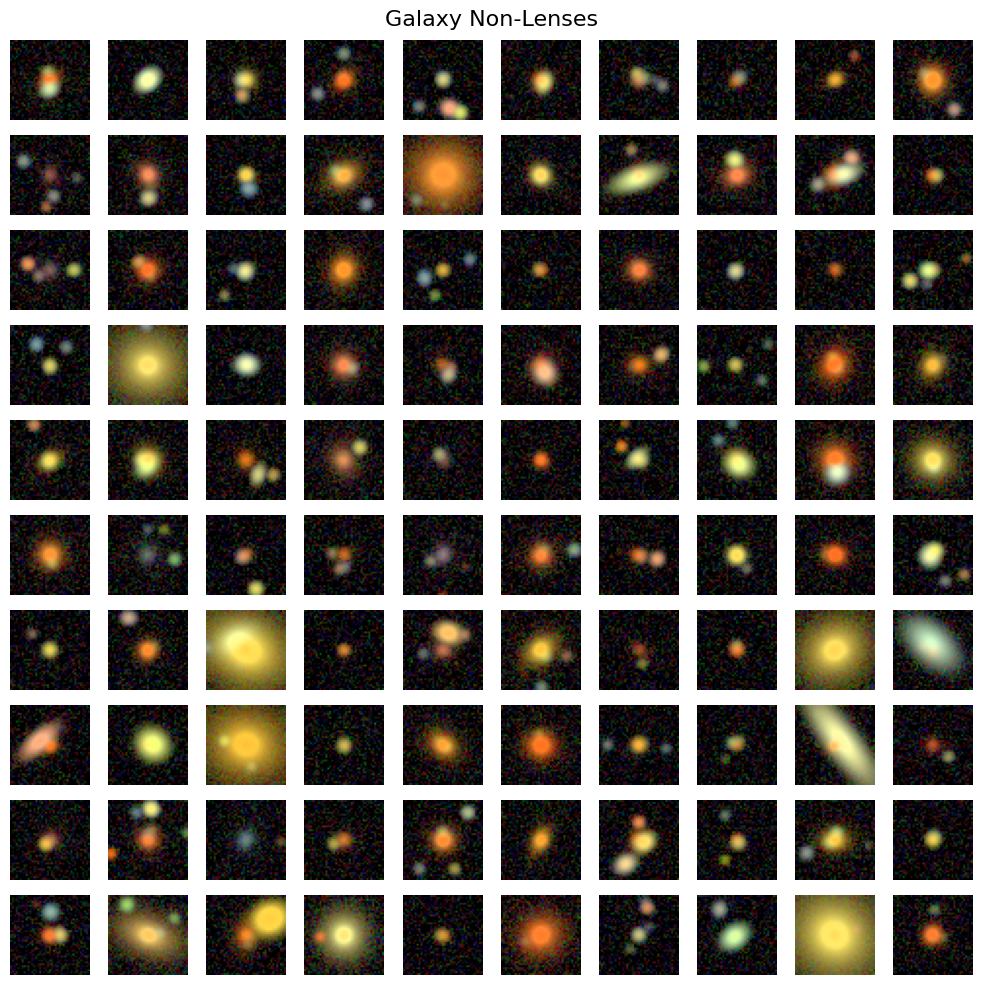

In [8]:
fp_galaxy_galaxy_pop = FalsePositivePop(
    central_galaxy_population=lens_galaxy_pop,
    intruder_populations=source_galaxy_pop,
    intruder_number_choices=[
        1,
        2,
    ],  # places 1 or 2 source galaxies near the lens galaxy to create a non-lens system with multiple nearby galaxies
    cosmo=cosmo,
    include_central_galaxy_light=True,
    test_area_factor=1,
)
galaxy_galaxy_nonlenses = fp_galaxy_galaxy_pop.draw_false_positive(1000)

# field galaxies
for nonlens in galaxy_galaxy_nonlenses:
    nonlens.add_field_galaxies(
        field_galaxies=field_galaxy_pop.draw_galaxies(area=Quantity(50, "arcsec2"))
    )

plot_montage(
    galaxy_galaxy_nonlenses, number_to_plot=100, plot_title="Galaxy Non-Lenses"
);

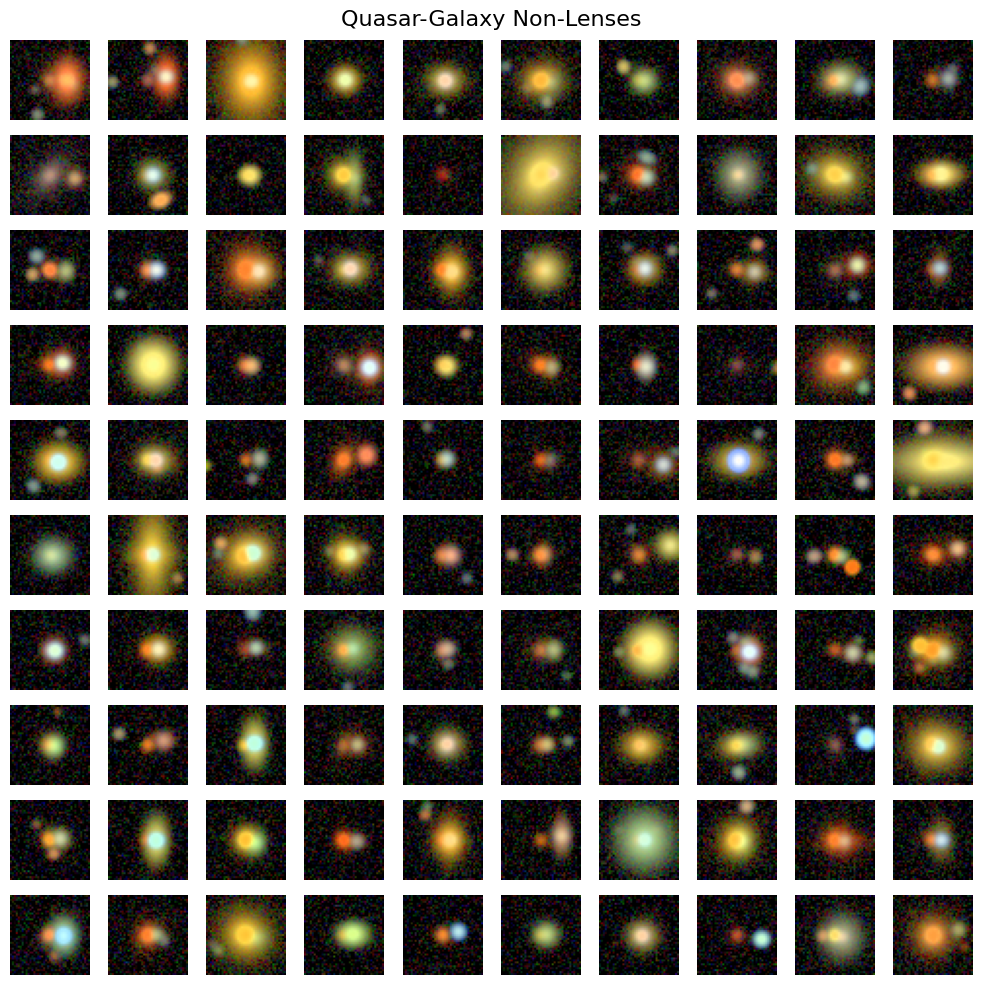

In [ ]:
fp_qso_qso_pop = FalsePositivePop(
    central_galaxy_population=lens_galaxy_pop,
    intruder_populations=[source_quasar_host_pop],
    intruder_number_choices=[
        [1]
    ],  # places 1 quasar near the lens galaxy to create a non-lens system with a single nearby point source
    cosmo=cosmo,
    clustering_mode="ring",  # places sources in a ring-like clustering around the deflector, which can create more realistic false positives by mimicking the typical configuration of lensed images around a lens galaxy
    include_central_galaxy_light=True,
)
qso_qso_nonlenses = fp_qso_qso_pop.draw_false_positive(100)

# field galaxies
for nonlens in qso_qso_nonlenses:
    nonlens.add_field_galaxies(
        field_galaxies=field_galaxy_pop.draw_galaxies(area=Quantity(50, "arcsec2"))
    )

plot_montage(
    qso_qso_nonlenses, number_to_plot=100, plot_title="Quasar-Galaxy Non-Lenses"
);

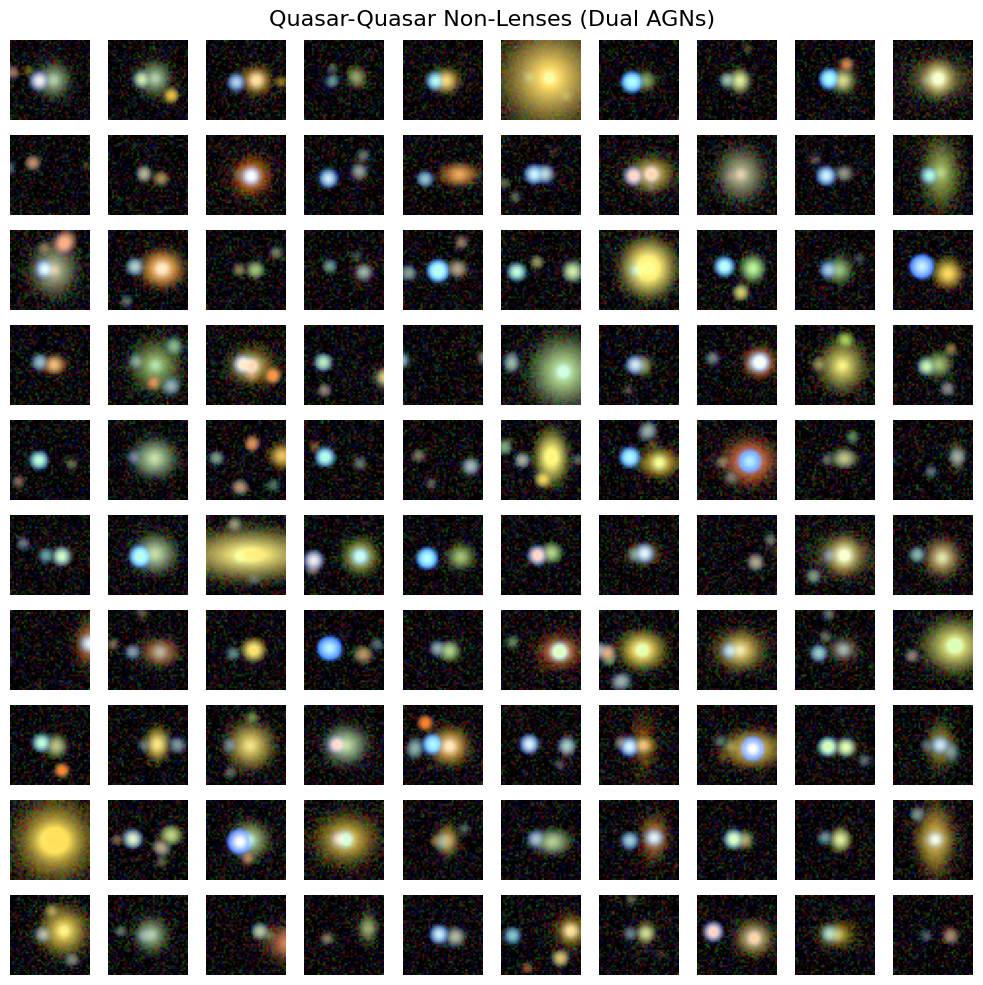

In [128]:
# Dual AGN Non-Lenses
fp_qso_qso_pop = FalsePositivePop(
    central_galaxy_population=lens_galaxy_pop,
    intruder_populations=[source_quasar_host_pop, source_quasar_pop],
    intruder_number_choices=[[1], [1]],
    cosmo=cosmo,
    clustering_mode="ring",
    include_central_galaxy_light=False,
)
qso_qso_nonlenses = fp_qso_qso_pop.draw_false_positive(100)

# field galaxies
for nonlens in qso_qso_nonlenses:
    nonlens.add_field_galaxies(
        field_galaxies=field_galaxy_pop.draw_galaxies(area=Quantity(50, "arcsec2"))
    )

plot_montage(
    qso_qso_nonlenses,
    number_to_plot=100,
    plot_title="Quasar-Quasar Non-Lenses (Dual AGNs)",
);

## Simulating Lenses with Field Galaxies

In [133]:
lensed_quasars_pop = LensPop(
    deflector_population=lens_galaxy_pop,
    source_population=source_quasar_host_pop,
    cosmo=cosmo,
    sky_area=Quantity(1000, "deg2"),
)

kwargs_lens_cut_plot = {
    "min_image_separation": 0.5,
    # "max_image_separation": 30,
    # "mag_arc_limit": {"i": 23},
    "second_brightest_image_cut": {"i": 26},
}

lensed_quasars = lensed_quasars_pop.draw_population(
    kwargs_lens_cuts=kwargs_lens_cut_plot, speed_factor=1000
)

# add field galaxies to the lensed quasar systems to create more realistic images
for lens in lensed_quasars:
    lens.add_field_galaxies(
        field_galaxies=field_galaxy_pop.draw_galaxies(area=Quantity(50, "arcsec2"))
    )

print(f"Number of lensed quasars drawn: {len(lensed_quasars)}")

Number of lensed quasars drawn: 100


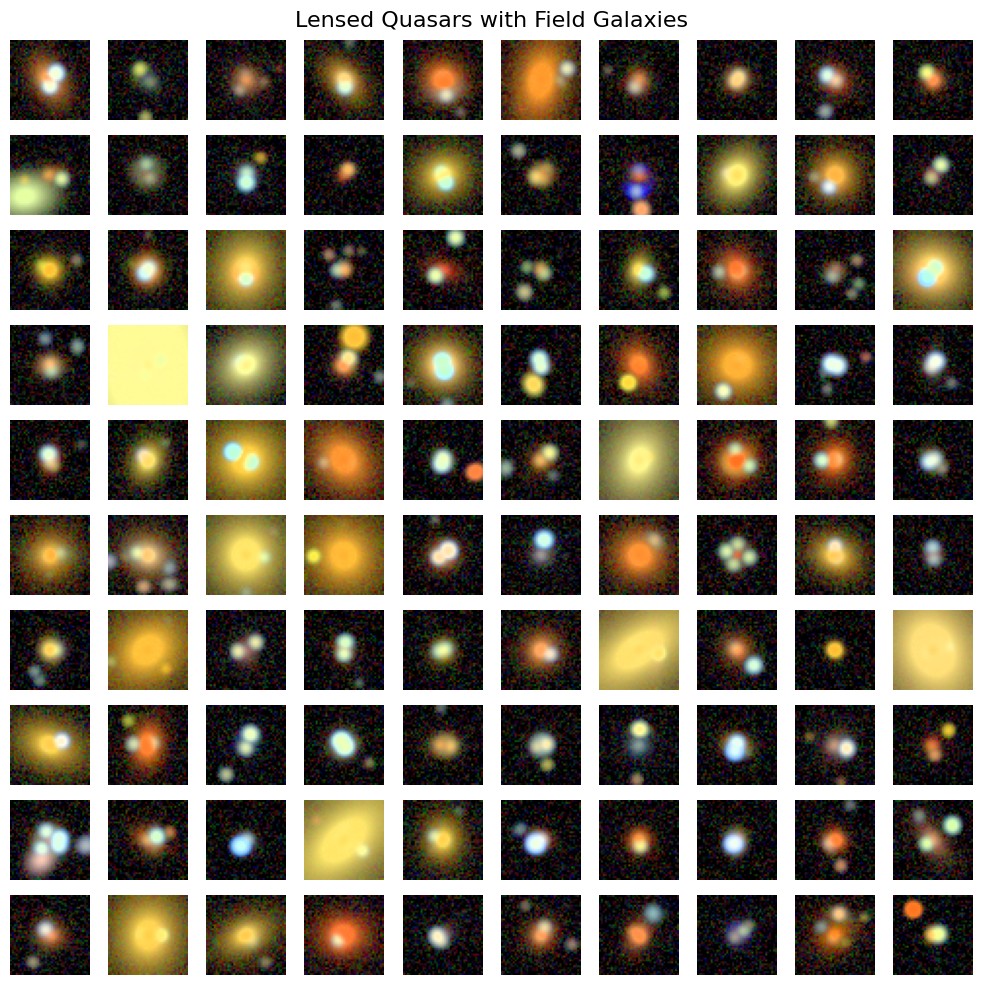

In [134]:
# plot a montage of the lensed quasars
plot_montage(
    lensed_quasars,
    number_to_plot=100,
    plot_title="Lensed Quasars with Field Galaxies",
);

In [144]:
lensed_galaxies_pop = LensPop(
    deflector_population=lens_galaxy_pop,
    source_population=source_galaxy_pop,
    cosmo=cosmo,
    sky_area=Quantity(100, "deg2"),
)

kwargs_lens_cut_plot = {
    "min_image_separation": 0.5,
    # "max_image_separation": 30,
    "mag_arc_limit": {"i": 23},
    # "second_brightest_image_cut": {"i": 26},
}

lensed_galaxies = lensed_galaxies_pop.draw_population(
    kwargs_lens_cuts=kwargs_lens_cut_plot, speed_factor=10000
)

# add field galaxies to the lensed galaxy systems to create more realistic images
for lens in lensed_galaxies:
    lens.add_field_galaxies(
        field_galaxies=field_galaxy_pop.draw_galaxies(area=Quantity(50, "arcsec2"))
    )

print(f"Number of lensed galaxies drawn: {len(lensed_galaxies)}")

Number of lensed galaxies drawn: 81


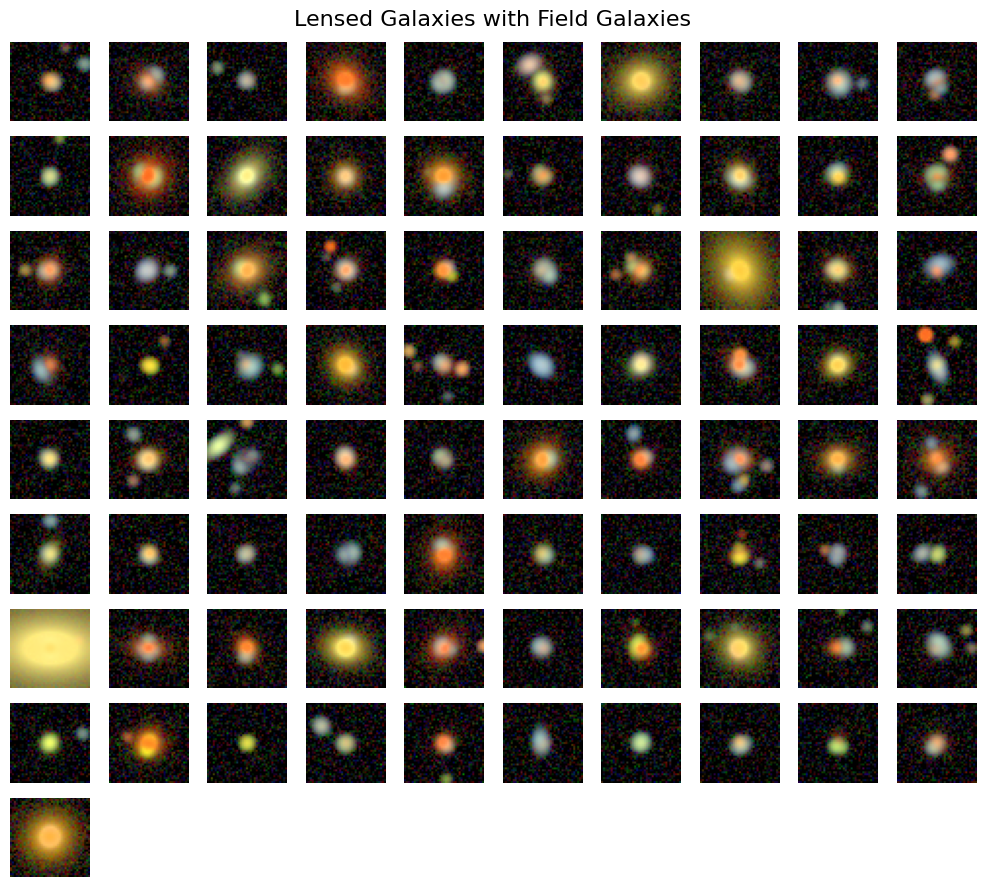

In [145]:
# plot a montage of the lensed galaxies
plot_montage(
    lensed_galaxies,
    number_to_plot=100,
    plot_title="Lensed Galaxies with Field Galaxies",
);